In [230]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction

This notebook is a follow-up to `ising/introduction.ipynb`. The background theory is thoroughly explained in that notebook. Here, I expand upon the work in that notebook by allowing spins to point in any direction. This means that the model is no longer an Ising model but rather an XY model.

The main reference is the following program

https://www.compadre.org/stpbook/statistical-mechanics-2/ex9_3.cfm

which is an accompaniment to this textbook:

H. Gould and J. Tobochnik, Statistical and Thermal Physics: With Computer Applications, 2nd ed., Princeton University Press (2021)

# XY model: Main Changes

## Hamiltonian

In the Ising model, the reduced (ie using dimensionless quantities as much as possible) Hamiltonian is

$$\tilde E=-\sum_{\langle i,j\rangle}\sigma_i\sigma_j-H\sum_i\sigma_i.$$

In the XY model, the interaction term $\sigma_i\sigma_j$ becomes

$$\vec s_i\cdot \vec s_j \equiv \cos(\theta_i - \theta_j).$$

As for the external field term $H\sum_i\sigma_i$, our external field is now a vector $\vec H$ that can point in any direction $\phi$ that we want. This thus becomes

$$\sum_i \vec H \cdot \vec s_i \equiv H \sum_i \cos(\phi - \theta_i).$$

Hence, the reduced Hamiltonian for our model is

$$\boxed{\tilde E = -\sum_{\braket{i,j}}\cos(\theta_i-\theta_j)-H \sum_i \cos(\phi - \theta_i)}$$

## Metropolis Algorithm

The main change is that we still pick a random spin, but instead of flipping it, we randomly rotate it within the bounds $(-\delta, \delta)$, represented in code as `delta`. A higher `delta` may propose more extreme rotations that may be more likely to be rejected, whereas a lower `delta` may cause the system to evolve too slowly. Picking a good `delta` value may be relevant to the speed of the evolution.

# Simulation
## Parameters
The variables in this code block can be modified for different results. All other code blocks should not be modified.

In [231]:
L = 20 # number of spins in one side of the square lattice (so total there are N = L^2 spins)

# hamiltonian parameters
H = 0 # H = mu_s * B / J
phi = 0
BJ = 5

# metropolis parameters
delta = np.pi / 4 # the maximum a spin can rotate in one iteration
num_sweeps = 1000 # number of monte carlo sweeps = num_sweeps * N monte carlo iterations
save_every = L**2 # save snapshots of the lattice for animation every <save_every> monte carlo iteration

# initial portion of run to discard so only equilibrium states are considered for stats calculations
burn_in_fraction = 0.5 

### Basic Metropolis Simulation

In [232]:
# generate lattice of random spins
lattice = ut.generate_lattice(L)
energy = ut.get_energy(lattice, H, phi)

# execute algorithm
N = L**2
steps = N * num_sweeps
final_lattice, total_spins_x, total_spins_y, energies, frames = ut.metropolis(lattice, steps, BJ, H, phi, energy, delta, save_every)

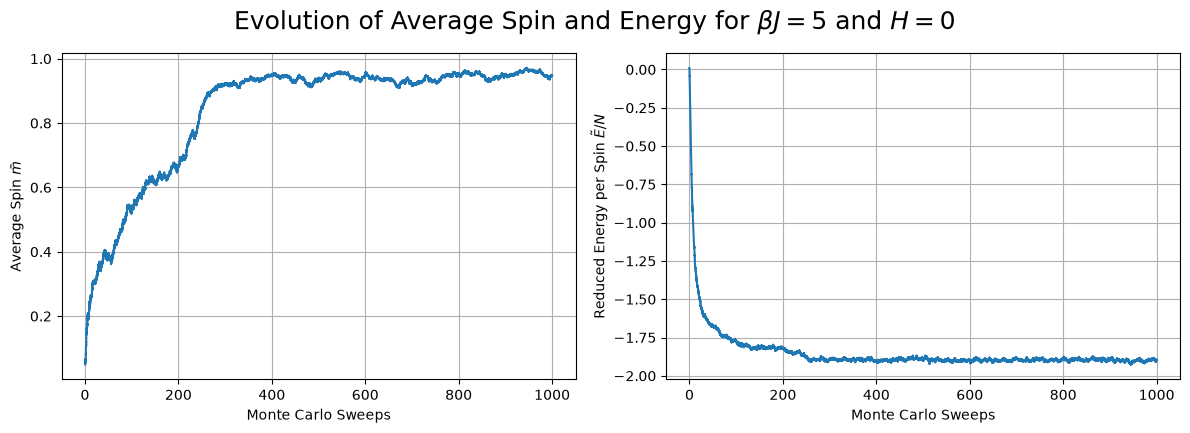

In [233]:
total_spins = np.sqrt(total_spins_x ** 2 + total_spins_y ** 2)
sweeps = np.arange(len(total_spins)) / N

# plot evolution of average spin and energy
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
ax.plot(sweeps, total_spins/N)
ax.set_xlabel('Monte Carlo Sweeps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()

ax = axes[1]
ax.plot(sweeps, energies/N)
ax.set_xlabel('Monte Carlo Sweeps')
ax.set_ylabel(r'Reduced Energy per Spin $\tilde E/N$')
ax.grid()

fig.tight_layout()
fig.suptitle(rf'Evolution of Average Spin and Energy for $\beta J={BJ}$ and $H={H}$', y=1.07, size=18)

plt.show()


# note that reduced magnetisation is exactly the same as average spin

### Lattice Evolution Animation
A GIF of either arrows or colours is generated to depict the evolution, depending on the lattice size. Arrows represent the spins more directly and allow for vortices to be observed but become unwieldly for too large `L`.

<p align="center">
  <img src="images/twilight.png" alt="Twilight colour scheme" width="400" align="center"/>
</p>

In [234]:
mode = "arrows" if L <= 24 else "colours"
ut.make_gif(frames, f'images/xy_{mode}.gif', fps=32, mode=mode)

![Animation](images/xy_arrows.gif)

# Magnetisation

We maintain the approach in the previous notebook of measured reduced (ie dimensionless) magnetisation. However, the calculation of magnetisation changes slightly. Now, reduced magnetisation is given by

$$\tilde m \equiv \left|\vec{\tilde m}\right| = \frac 1 N \left|\sum_i \vec s_i \right|.$$

This is computed in the code as 

$$\tilde m = \frac 1 N \sqrt{\left(\sum_i\cos\theta_i\right)^2+\left(\sum_i\sin\theta_i\right)^2}.$$

In [235]:
start = int(burn_in_fraction * len(total_spins_x))

equilibrium_spins_x = total_spins_x[start:]
equilibrium_spins_y = total_spins_y[start:]
equilibrium_energies = energies[start:]

m = np.sqrt(equilibrium_spins_x**2 + equilibrium_spins_y**2) / N
mean_m = np.mean(m)
print(f'Magnetisation is {mean_m:.5f}')

Magnetisation is 0.94396


# Susceptibility
To define reduced susceptibility, we first need to define $m_\parallel$, the component of magnetisation parallel to the external magnetic field

$$\tilde m_\parallel := \vec{\tilde m} \cdot \hat H = \frac 1 N \sum_i \cos(\theta_i - \phi) = \tilde m_x \cos\phi + \tilde m_y \sin\phi.$$


Reduced susceptibility is then given by

$$\tilde\chi = \beta JN \ \text{Var}\left(\tilde m_\parallel\right)$$


In [236]:
m_parallel = (equilibrium_spins_x * np.cos(phi) + equilibrium_spins_y * np.sin(phi)) / N
chi = BJ * N * np.var(m_parallel)
print(f'Magnetic susceptibility is {chi:.5f}')

Magnetic susceptibility is 4.42985
